# 📊 FULL EDA NOTEBOOK — GROUP BY MASTERCLASS

Focus: Learn GROUP BY through business questions.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# INPUT_PATH = "."                  # current folder
# INPUT_PATH = "./data"             # subfolder

# absolute path (Mac)
INPUT_PATH = "/Users/max/mp/github/data-warehousing/syllabus/week01-Foundations-SQL-for-Analytics/group_by_examples"

In [5]:
con = duckdb.connect()

In [6]:
con.execute(f"""
CREATE OR REPLACE TABLE sales AS
SELECT * FROM read_csv_auto('{INPUT_PATH}/sales.csv');
""")

## 🔍 Data Preview

In [7]:
con.execute("SELECT * FROM sales LIMIT 5").df()

,transaction_id,transaction_date,product_name,price,quantity,discount,gender,country,age,sales_amount
0,1,2024-02-15,LAPTOP,1500,1,0.02,FEMALE,FRANCE,56,1470.0
1,2,2025-11-07,BIKE,500,1,0.02,FEMALE,USA,37,588.0
2,3,2025-03-12,TV,800,2,0.19,FEMALE,MEXICO,65,1296.0
3,4,2024-10-17,LAPTOP,1500,1,0.03,MALE,CHINA,29,1455.0
4,5,2023-06-20,IPAD,900,1,0.07,FEMALE,CANADA,66,920.7


## 📊 Country Distribution
**Business Question:** Which countries generate most transactions?

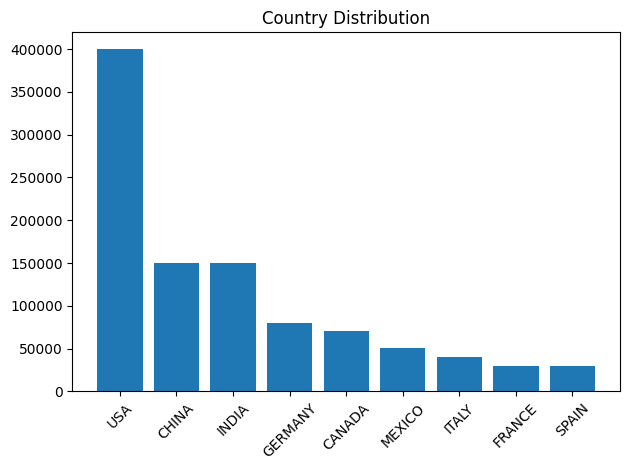

In [8]:
df = con.execute("""SELECT country, COUNT(*) AS cnt
FROM sales
GROUP BY country
ORDER BY cnt DESC""").df()

plt.figure()
if "bar" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "bar" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Country Distribution")
plt.tight_layout()
plt.show()

## 📊 Gender Distribution
**Business Question:** What is the gender split?

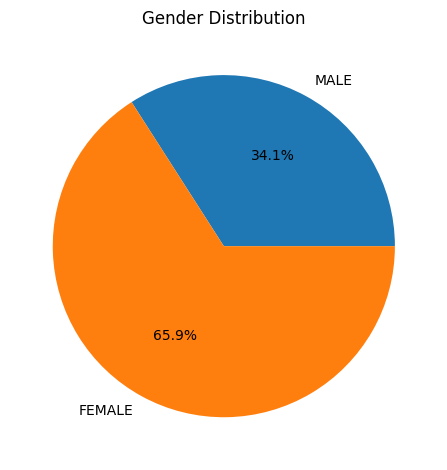

In [9]:
df = con.execute("""SELECT gender, COUNT(*) AS cnt
FROM sales
GROUP BY gender""").df()

plt.figure()
if "pie" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "pie" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

## 📊 Product Popularity
**Business Question:** Which products sell the most?

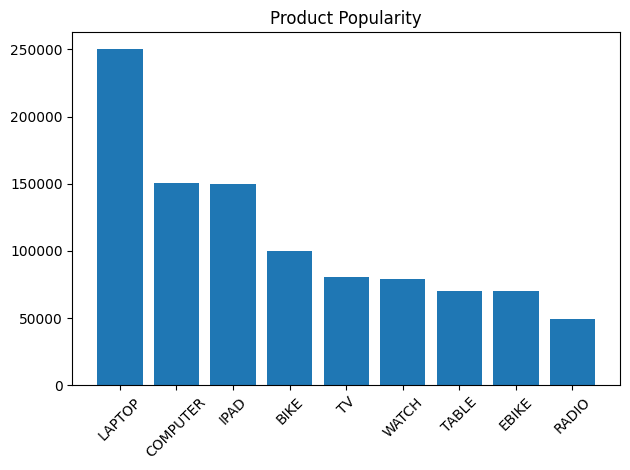

In [10]:
df = con.execute("""SELECT product_name, COUNT(*) AS cnt
FROM sales
GROUP BY product_name
ORDER BY cnt DESC""").df()

plt.figure()
if "bar" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "bar" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Product Popularity")
plt.tight_layout()
plt.show()

## 📊 Revenue by Country
**Business Question:** Which countries generate most revenue?

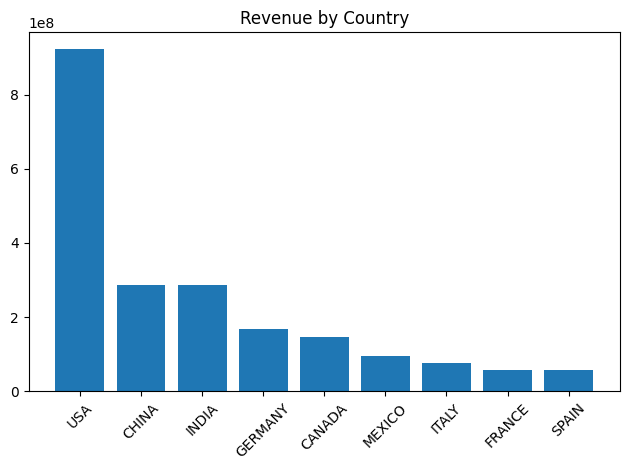

In [11]:
df = con.execute("""SELECT country, SUM(sales_amount) AS revenue
FROM sales
GROUP BY country
ORDER BY revenue DESC""").df()

plt.figure()
if "bar" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "bar" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Revenue by Country")
plt.tight_layout()
plt.show()

## 📊 Revenue by Product
**Business Question:** Which products generate most revenue?

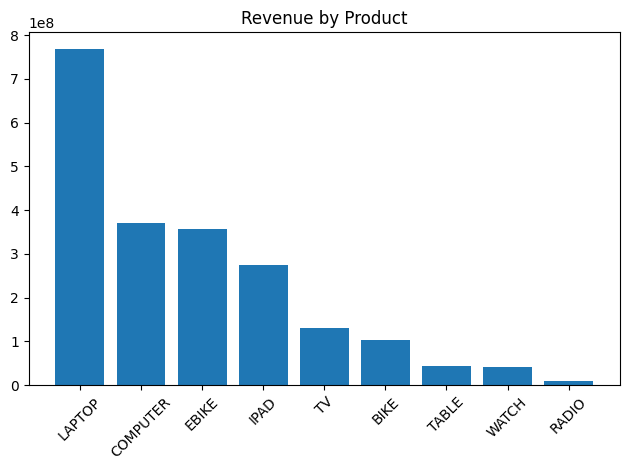

In [12]:
df = con.execute("""SELECT product_name, SUM(sales_amount) AS revenue
FROM sales
GROUP BY product_name
ORDER BY revenue DESC""").df()

plt.figure()
if "bar" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "bar" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Revenue by Product")
plt.tight_layout()
plt.show()

## 📊 Revenue by Gender
**Business Question:** Who spends more?

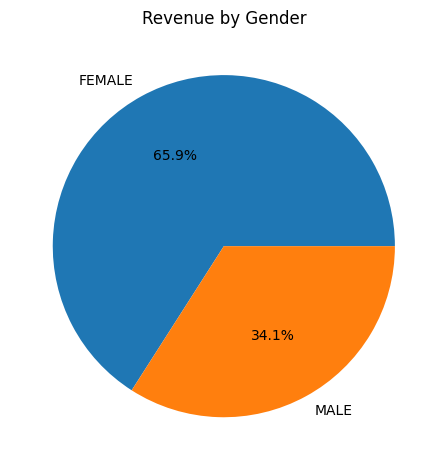

In [13]:
df = con.execute("""SELECT gender, SUM(sales_amount) AS revenue
FROM sales
GROUP BY gender""").df()

plt.figure()
if "pie" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "pie" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Revenue by Gender")
plt.tight_layout()
plt.show()

## 📊 Age Group Revenue
**Business Question:** Which age group spends most?

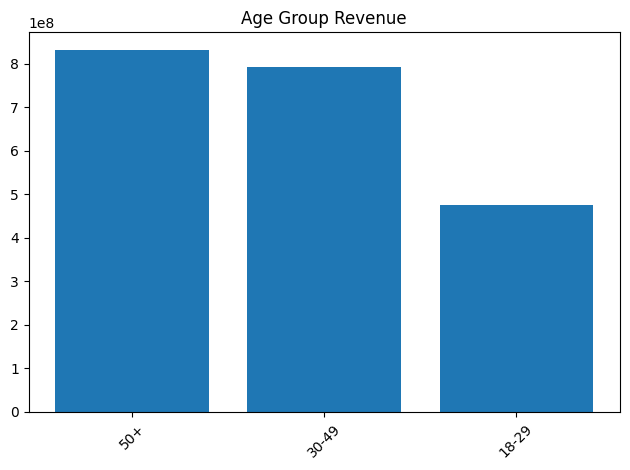

In [14]:
df = con.execute("""SELECT 
CASE 
 WHEN age < 30 THEN '18-29'
 WHEN age < 50 THEN '30-49'
 ELSE '50+'
END AS age_group,
SUM(sales_amount) AS revenue
FROM sales
GROUP BY age_group""").df()

plt.figure()
if "bar" == "bar":
    plt.bar(df[df.columns[0]], df[df.columns[1]])
elif "bar" == "pie":
    plt.pie(df[df.columns[1]], labels=df[df.columns[0]], autopct='%1.1f%%')

plt.xticks(rotation=45)
plt.title("Age Group Revenue")
plt.tight_layout()
plt.show()